In [1]:
##### Overlays capital and labor with priority maps: calculations and figures

import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import matplotlib.transforms as transforms
from matplotlib.lines import Line2D
import rasterio.features
from matplotlib import gridspec
import rioxarray as rio
import matplotlib.colors as mcolors
from rasterio.plot import show
import os
import textwrap

In [2]:
##### Load data

# Get the current working directory
cd = Path.cwd().parent 

# capital rasters
capital = f"{cd}/Results/Raster_model/reprojected/rescaled_capital_USD.tif"
capital_country_avg = f"{cd}/Results/Raster_model/reprojected/rescaled_capital_USD_country_avg.tif"

# labor rasters
labor = f"{cd}/Results/Raster_model/reprojected/rescaled_jobs.tif"
labor_country_avg = f"{cd}/Results/Raster_model/reprojected/rescaled_jobs_country_avg.tif"

# production raster
production = f"{cd}/Results/Raster_model/reprojected/total_production_tonnes_2020.tif"

# priority raster
# 0 = no in top 30%, 1 = in top 30%, not PA, 2 = in top 30%, already PA
biodiversity_with_PA = f"{cd}/Data/Clean/Priority_areas/biodiversity_with_PA.tif"

# country boundaries 
country_shp = gpd.read_file("/Users/carinamanitius/Documents/Data/Admin_Boundaries/gadm_410-levels.gpkg", layer='ADM_0')
country_simple = gpd.read_file(f"{cd}/Data/Clean/Geographies/country_geo.shp")
country_codes = pd.read_csv(f"{cd}/Data/Correspondence_tables/country_names.csv", encoding="cp1252")

# Import country data
national_capital = pd.read_csv(f"{cd}/Results/Raster_model/intermediate_outputs/national_scaling_factors_capital.csv")
national_labor = pd.read_csv(f"{cd}/Results/Raster_model/intermediate_outputs/national_scaling_factors_labor.csv")

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/priority_areas"

##### Figure 1: % of global capital, labor, production in priority areas

In [3]:
##### Create global summary table of capital, labor, and production in priority areas

# Read array 
def read_array(path, band=1):
    with rasterio.open(path) as src:
        arr = src.read(band).astype(float)
        nodata = src.nodata
        if nodata is not None:
            arr[arr == nodata] = np.nan
    return arr

# Priority classification raster
priority_arr = read_array(biodiversity_with_PA)

# Observed/model values
value_rasters = {
    "Capital": capital,
    "Labor": labor,
    "Production": production,
}

# Country-average values
country_avg_rasters = {
    "Capital": capital_country_avg,
    "Labor": labor_country_avg,
    # No production country-average raster is currently provided
}

summary_rows = []

for variable, path in value_rasters.items():
    value_arr = read_array(path)
    global_total = np.nansum(value_arr)

    additional = np.nansum(value_arr[priority_arr == 1])
    already = np.nansum(value_arr[priority_arr == 2])
    total = additional + already

    summary_rows.append({
        "Variable": variable,
        "Additional_priority": additional,
        "Already_in_PA": already,
        "Total_priority": total,
        "Pct_additional": 100 * additional / global_total,
        "Pct_already": 100 * already / global_total,
        "Pct_total": 100 * total / global_total,
        "Global_total": global_total,
    })

summary_df = pd.DataFrame(summary_rows)

# Calculate country-average estimates for comparison
country_avg_summary = {}

for variable, path in country_avg_rasters.items():
    value_arr = read_array(path)
    global_total = np.nansum(value_arr)

    additional = np.nansum(value_arr[priority_arr == 1])
    already = np.nansum(value_arr[priority_arr == 2])
    total = additional + already

    country_avg_summary[variable] = {
        "Global_total": global_total,
        "Total_priority": total,
        "Pct_total": 100 * total / global_total,
    }

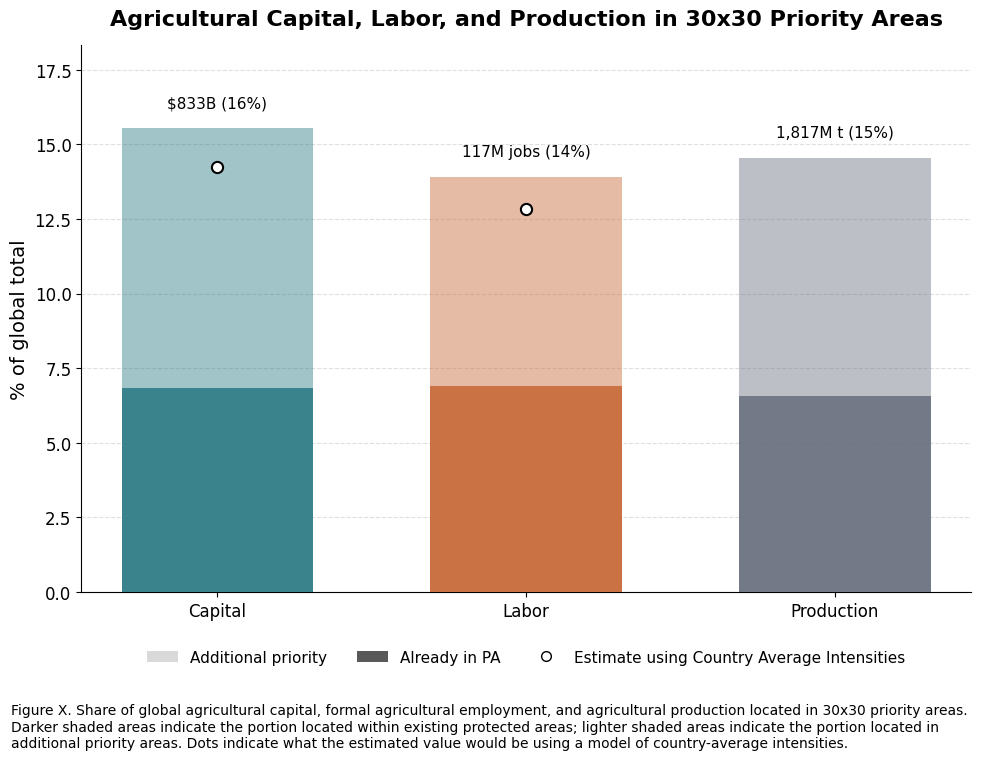

In [4]:
##### Plot figure: % of global capital, labor, production in priority regions (bar chart)

COLORS = {
    "Capital": "#2F7C87",
    "Labor": "#C96A3B",
    "Production": "#6B7280",
}

STATUS_COLORS = {
    "Additional priority": "#D9D9D9",
    "Already in PA": "#595959",
}

plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
})

variables = ["Capital", "Labor", "Production"]
x = np.arange(len(variables))
width = 0.62

fig, ax = plt.subplots(figsize=(10, 7))

for i, variable in enumerate(variables):
    row = summary_df.loc[
        summary_df["Variable"] == variable
    ].iloc[0]

    # Keep variable-specific colors in the bars.
    # Darker shade = already PA; lighter shade = additional priority.
    # Use alpha to distinguish the two portions.
    ax.bar(
        i,
        row["Pct_already"],
        width,
        color=COLORS[variable],
        alpha=0.95,
        zorder=3,
    )

    ax.bar(
        i,
        row["Pct_additional"],
        width,
        bottom=row["Pct_already"],
        color=COLORS[variable],
        alpha=0.45,
        zorder=3,
    )

    # Absolute total + percentage label
    value = row["Total_priority"]

    if variable == "Capital":
        value_label = (
            f"${value / 1e9:,.0f}B"
            if value >= 1e9
            else f"${value / 1e6:,.0f}M"
        )
    elif variable == "Labor":
        value_label = (
            f"{value / 1e6:,.0f}M jobs"
            if value >= 1e6
            else f"{value / 1e3:,.0f}K jobs"
        )
    else:
        value_label = (
            f"{value / 1e6:,.0f}M t"
            if value >= 1e6
            else f"{value / 1e3:,.0f}K t"
        )

    ax.text(
        i,
        row["Pct_total"] + 0.6,
        f"{value_label} ({row['Pct_total']:.0f}%)",
        ha="center",
        va="bottom",
        fontsize=11,
    )

    # Country-average estimate
    if variable in country_avg_summary:
        country_avg_pct = country_avg_summary[variable]["Pct_total"]

        ax.scatter(
            i,
            country_avg_pct,
            marker="o",
            s=65,
            facecolor="white",
            edgecolor="black",
            linewidth=1.5,
            zorder=6,
        )

ax.set_xticks(x)
ax.set_xticklabels(variables)
ax.set_ylabel("% of global total")

ax.set_title(
    "Agricultural Capital, Labor, and Production in 30x30 Priority Areas",
    pad=14,
    fontweight="bold",
)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
ax.set_axisbelow(True)
ax.set_ylim(0, max(summary_df["Pct_total"]) * 1.18)

# Simplified five-item legend
legend_elements = [
    Patch(facecolor=STATUS_COLORS["Additional priority"], label="Additional priority"),
    Patch(facecolor=STATUS_COLORS["Already in PA"], label="Already in PA"),
    Line2D(
        [0],
        [0],
        marker="o",
        color="black",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=7,
        linewidth=0,
        label="Estimate using Country Average Intensities",
    ),
]

ax.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    frameon=False,
)

fig.text(
    0.02,
    -0.02,
    "Figure X. Share of global agricultural capital, formal agricultural employment, "
    "and agricultural production located in 30x30 priority areas. Darker shaded areas "
    "indicate the portion located within existing protected areas; lighter shaded areas "
    "indicate the portion located in additional priority areas. Dots indicate what the "
    "estimated value would be using a model of country-average intensities.",
    ha="left",
    va="top",
    fontsize=10,
    wrap=True,
)

plt.tight_layout()
plt.savefig(
    f"{fd}/Figure_1_global_biodiversity_summary.png",
    dpi=250,
    bbox_inches="tight",
)
plt.show()

#### Figure 2: butterfly chart by countries

In [5]:
##### Prepare country-level data on capital, labor, and production in priority areas 

# Merge country codes
country_shp = country_shp.merge(
    country_codes,
    left_on="GID_0",
    right_on="SHP_code",
    how="left",
)

# Use the capital raster as the reference grid
with rasterio.open(capital) as ref:
    ref_transform = ref.transform
    ref_shape = (ref.height, ref.width)
    ref_crs = ref.crs

country_shp_proj = (
    country_shp.to_crs(ref_crs)
    if country_shp.crs != ref_crs
    else country_shp.copy()
).reset_index(drop=True)

# Rasterize countries
shapes = (
    (geom, i)
    for i, geom in enumerate(country_shp_proj.geometry)
    if geom is not None
)

country_id_arr = rasterio.features.rasterize(
    shapes=shapes,
    out_shape=ref_shape,
    transform=ref_transform,
    fill=-1,
    dtype="int32",
)

n_countries = len(country_shp_proj)
row_to_iso3 = country_shp_proj["ISO3"].to_dict()


def zonal_sum_by_country(
    value_arr,
    priority_arr,
    class_value,
    country_id_arr,
    n_countries,
):
    valid = (
        (country_id_arr >= 0)
        & (priority_arr == class_value)
        & ~np.isnan(value_arr)
    )

    return np.bincount(
        country_id_arr[valid],
        weights=value_arr[valid],
        minlength=n_countries,
    )


# Observed/model rasters
value_rasters = {
    "Capital": capital,
    "Labor": labor,
    "Production": production,
}

# Country-average rasters
country_avg_rasters = {
    "Capital": capital_country_avg,
    "Labor": labor_country_avg,
    # No production country-average raster currently provided
}


# National totals for each variable
national_totals = {}

for variable, path in value_rasters.items():
    arr = read_array(path)
    valid = (country_id_arr >= 0) & ~np.isnan(arr)

    totals = np.bincount(
        country_id_arr[valid],
        weights=arr[valid],
        minlength=n_countries,
    )

    national_totals[variable] = {
        row_to_iso3[i]: totals[i]
        for i in range(n_countries)
    }


# Country-level priority totals
country_rows = []

for variable, path in value_rasters.items():
    arr = read_array(path)

    for class_value, class_name in [
        (1, "Additional priority"),
        (2, "Already in PA"),
    ]:
        sums = zonal_sum_by_country(
            arr,
            priority_arr,
            class_value,
            country_id_arr,
            n_countries,
        )

        for i in range(n_countries):
            iso3 = row_to_iso3[i]
            national_total = national_totals[variable].get(
                iso3,
                np.nan,
            )

            country_rows.append({
                "ISO3": iso3,
                "Variable": variable,
                "Class": class_name,
                "Sum": sums[i],
                "National_Total": national_total,
            })

country_df = pd.DataFrame(country_rows)


# Global totals
global_totals = {
    variable: np.nansum(read_array(path))
    for variable, path in value_rasters.items()
}

country_df["Pct_of_national"] = np.where(
    country_df["National_Total"] > 0,
    100 * country_df["Sum"] / country_df["National_Total"],
    np.nan,
)

country_df["Global_Total"] = country_df["Variable"].map(global_totals)

country_df["Pct_of_global"] = (
    100 * country_df["Sum"] / country_df["Global_Total"]
)


# Total priority value by country
country_totals = (
    country_df
    .groupby(["ISO3", "Variable"], as_index=False)
    .agg(
        Priority_Total=("Sum", "sum"),
        National_Total=("National_Total", "first"),
        Pct_of_national=("Pct_of_national", "sum"),
        Pct_of_global=("Pct_of_global", "sum"),
    )
)


# Country-average estimates

country_avg_rows = []

for variable, path in country_avg_rasters.items():

    arr = read_array(path)

    # Global priority-area total under the country-average model.
    global_avg_priority_total = np.nansum(
        arr[
            (priority_arr == 1) | (priority_arr == 2)
        ]
    )

    # Global total under the country-average model.
    global_avg_total = np.nansum(arr)

    national_avg = np.zeros(n_countries)

    valid = (
        (country_id_arr >= 0)
        & ~np.isnan(arr)
    )

    national_avg = np.bincount(
        country_id_arr[valid],
        weights=arr[valid],
        minlength=n_countries,
    )

    for class_value, class_name in [
        (1, "Additional priority"),
        (2, "Already in PA"),
    ]:

        sums = zonal_sum_by_country(
            arr,
            priority_arr,
            class_value,
            country_id_arr,
            n_countries,
        )

        for i in range(n_countries):

            iso3 = row_to_iso3[i]

            country_avg_rows.append({
                "ISO3": iso3,
                "Variable": variable,
                "Class": class_name,
                "Sum": sums[i],
                "National_Total": national_avg[i],
                "Global_Avg_Priority_Total": global_avg_priority_total,
                "Global_Avg_Total": global_avg_total,
            })


country_avg_df = pd.DataFrame(country_avg_rows)


# Total priority-area value by country
country_avg_totals = (
    country_avg_df
    .groupby(
        ["ISO3", "Variable"],
        as_index=False,
    )
    .agg(
        Priority_Total=("Sum", "sum"),
        National_Total=("National_Total", "first"),
        Global_Avg_Priority_Total=(
            "Global_Avg_Priority_Total",
            "first",
        ),
        Global_Avg_Total=(
            "Global_Avg_Total",
            "first",
        ),
    )
)


# Share of the country's own total under the
# country-average-intensity model
country_avg_totals["Pct_of_national"] = np.where(
    country_avg_totals["National_Total"] > 0,
    100
    * country_avg_totals["Priority_Total"]
    / country_avg_totals["National_Total"],
    np.nan,
)


# Percentages
country_avg_totals["Pct_of_global"] = np.where(
    country_avg_totals["Global_Avg_Total"] > 0,
    100
    * country_avg_totals["Priority_Total"]
    / country_avg_totals["Global_Avg_Total"],
    np.nan,
)

/var/folders/48/ky2jtbmj31bfj15cr5gq480w0000gn/T/ipykernel_10558/3847116668.py:354: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


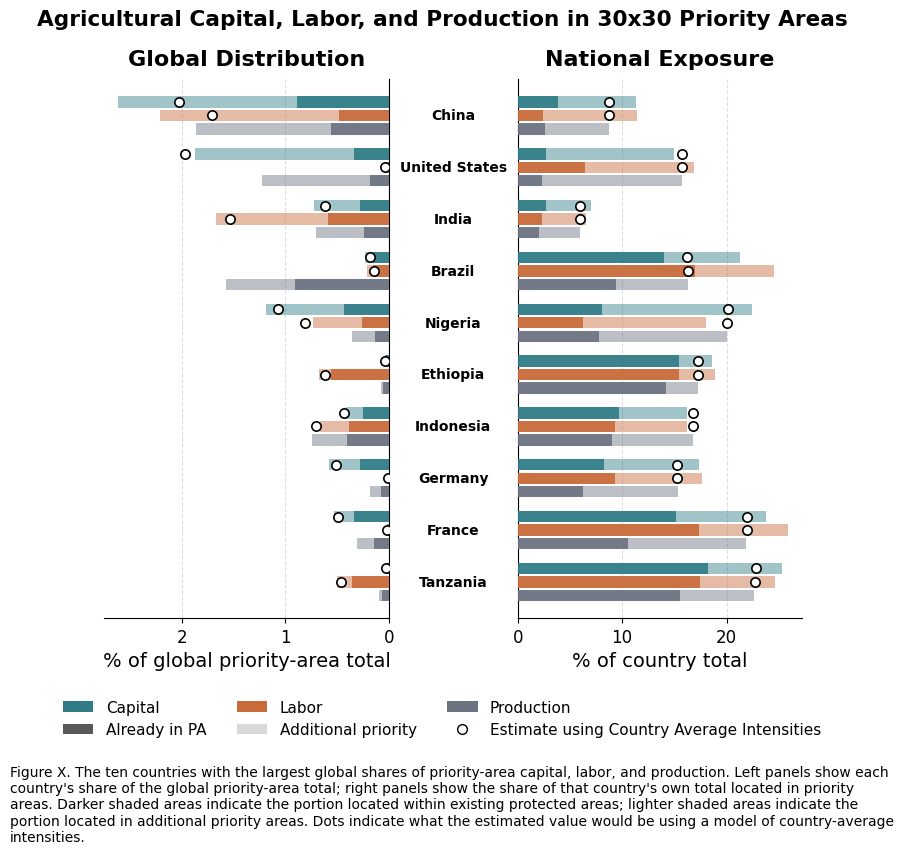

In [6]:
##### Plot country butterfly chart

def plot_country_butterfly(
    country_df,
    country_totals,
    country_avg_totals,
    country_shp_proj,
    top_n=10,
):

    # Rank separately by each variable and interleave rankings
    rankings = {}

    for variable in ["Capital", "Labor", "Production"]:
        rankings[variable] = (
            country_totals[
                (country_totals["Variable"] == variable)
                & (country_totals["ISO3"] != "OTHER")
            ]
            .sort_values(
                "Pct_of_global",
                ascending=False,
            )["ISO3"]
            .tolist()
        )

    country_list = []
    rank = 0

    while (
        len(country_list) < top_n
        and rank < max(len(v) for v in rankings.values())
    ):
        for variable in ["Capital", "Labor", "Production"]:
            ranked = rankings[variable]

            if (
                rank < len(ranked)
                and ranked[rank] not in country_list
            ):
                country_list.append(ranked[rank])

            if len(country_list) == top_n:
                break

        rank += 1

    name_col = next(
        (
            c
            for c in [
                "COUNTRY",
                "NAME_0",
                "Country",
                "country_name",
            ]
            if c in country_shp_proj.columns
        ),
        None,
    )

    if name_col:
        name_lookup = (
            country_shp_proj[
                ["ISO3", name_col]
            ]
            .drop_duplicates("ISO3")
            .set_index("ISO3")[name_col]
        )
    else:
        name_lookup = pd.Series(dtype=object)

    def get_values(iso3, variable, pct_col):
        sub = country_df[
            (country_df["ISO3"] == iso3)
            & (country_df["Variable"] == variable)
        ]

        already = sub.loc[
            sub["Class"] == "Already in PA",
            pct_col,
        ].sum()

        additional = sub.loc[
            sub["Class"] == "Additional priority",
            pct_col,
        ].sum()

        return already, additional

    n = len(country_list)
    bar_h = 0.22
    offset = bar_h + 0.04

    fig = plt.figure(
        figsize=(9, 0.5 * n + 2)
    )

    gs = gridspec.GridSpec(
        1,
        3,
        width_ratios=[4, 1.5, 4],
        wspace=0.05,
    )

    ax_left = fig.add_subplot(gs[0])
    ax_mid = fig.add_subplot(gs[1], sharey=ax_left)
    ax_right = fig.add_subplot(gs[2], sharey=ax_left)

    y_positions = np.arange(n)[::-1]

    for y, iso3 in zip(
        y_positions,
        country_list,
    ):

        for variable, y_off in [
            ("Capital", offset),
            ("Labor", 0),
            ("Production", -offset),
        ]:

            already_g, additional_g = get_values(
                iso3,
                variable,
                "Pct_of_global",
            )

            already_n, additional_n = get_values(
                iso3,
                variable,
                "Pct_of_national",
            )

            # Global distribution
            ax_left.barh(
                y + y_off,
                already_g,
                bar_h,
                color=COLORS[variable],
                alpha=0.95,
                zorder=3,
            )

            ax_left.barh(
                y + y_off,
                additional_g,
                bar_h,
                left=already_g,
                color=COLORS[variable],
                alpha=0.45,
                zorder=3,
            )

            # National exposure
            ax_right.barh(
                y + y_off,
                already_n,
                bar_h,
                color=COLORS[variable],
                alpha=0.95,
                zorder=3,
            )

            ax_right.barh(
                y + y_off,
                additional_n,
                bar_h,
                left=already_n,
                color=COLORS[variable],
                alpha=0.45,
                zorder=3,
            )

            # Country-average estimate
            avg_sub = country_avg_totals[
                (country_avg_totals["ISO3"] == iso3)
                & (country_avg_totals["Variable"] == variable)
            ]

            if not avg_sub.empty:

                avg_global = avg_sub[
                    "Pct_of_global"
                ].iloc[0]

                avg_national = avg_sub[
                    "Pct_of_national"
                ].iloc[0]

                # Dot on global-distribution side
                if pd.notna(avg_global):
                    ax_left.scatter(
                        avg_global,
                        y + y_off,
                        marker="o",
                        s=45,
                        facecolor="white",
                        edgecolor="black",
                        linewidth=1.2,
                        zorder=6,
                    )

                # Dot on national-exposure side
                if pd.notna(avg_national):
                    ax_right.scatter(
                        avg_national,
                        y + y_off,
                        marker="o",
                        s=45,
                        facecolor="white",
                        edgecolor="black",
                        linewidth=1.2,
                        zorder=6,
                    )

    # Axes
    ax_left.set_xlabel(
        "% of global priority-area total"
    )

    ax_left.invert_xaxis()

    ax_left.spines[
        ["top", "left"]
    ].set_visible(False)

    ax_left.grid(
        axis="x",
        linestyle="--",
        alpha=0.4,
        zorder=0,
    )

    ax_left.set_axisbelow(True)
    ax_left.set_title(
        "Global Distribution",
        fontweight="bold",
        pad=10,
    )

    ax_left.yaxis.set_visible(False)

    ax_right.set_xlabel(
        "% of country total"
    )

    ax_right.spines[
        ["top", "right"]
    ].set_visible(False)

    ax_right.grid(
        axis="x",
        linestyle="--",
        alpha=0.4,
        zorder=0,
    )

    ax_right.set_axisbelow(True)

    ax_right.set_title(
        "National Exposure",
        fontweight="bold",
        pad=10,
    )

    ax_right.yaxis.set_visible(False)

    ax_mid.axis("off")

    for y, iso3 in zip(
        y_positions,
        country_list,
    ):
        ax_mid.text(
            0.5,
            y,
            name_lookup.get(iso3, iso3),
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
        )

    ax_mid.set_xlim(0, 1)
    ax_left.set_ylim(-0.7, n - 0.3)

    # Simplified legend — order interleaved for column-major fill:
    # col1: Capital/Already in PA, col2: Labor/Additional priority, col3: Production/Estimate
    legend_elements = [
        Patch(
            facecolor=COLORS["Capital"],
            label="Capital",
        ),
        Patch(
            facecolor=STATUS_COLORS["Already in PA"],
            label="Already in PA",
        ),
        Patch(
            facecolor=COLORS["Labor"],
            label="Labor",
        ),
        Patch(
            facecolor=STATUS_COLORS["Additional priority"],
            label="Additional priority",
        ),
        Patch(
            facecolor=COLORS["Production"],
            label="Production",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            color="black",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=7,
            linewidth=0,
            label="Estimate using Country Average Intensities",
        ),
    ]

    fig.legend(
        handles=legend_elements,
        loc="lower center",
        ncol=3,
        bbox_to_anchor=(0.5, -0.08),
        frameon=False,
    )

    fig.suptitle(
        "Agricultural Capital, Labor, and Production in 30x30 Priority Areas",
        fontweight="bold",
        y=0.98,
    )

    fig.text(
        0.02,
        -0.10,
        "Figure X. The ten countries with the largest global shares of priority-area "
        "capital, labor, and production. Left panels show each country's share of the "
        "global priority-area total; right panels show the share of that country's own "
        "total located in priority areas. Darker shaded areas indicate the portion "
        "located within existing protected areas; lighter shaded areas indicate the "
        "portion located in additional priority areas. Dots indicate what the estimated "
        "value would be using a model of country-average intensities.",
        ha="left",
        va="top",
        fontsize=10,
        wrap=True,
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.93]
    )

    plt.savefig(
        f"{fd}/Figure_2_country_biodiversity.png",
        dpi=250,
        bbox_inches="tight",
    )

    plt.show()


plot_country_butterfly(
    country_df,
    country_totals,
    country_avg_totals,
    country_shp_proj,
)

#### Figure 3: butterfly chart by income group / UN region

In [7]:
##### Prep data by income group and UN region

geo_lookup = (
    country_shp_proj[
        ["ISO3", "UN_region", "income_group"]
    ]
    .drop_duplicates("ISO3")
)


def aggregate_to_group(
    country_df,
    geo_lookup,
    group_col,
    global_totals,      # <-- now passed in, keyed by Variable
):

    df = country_df.merge(
        geo_lookup[["ISO3", group_col]],
        on="ISO3",
        how="left",
    )

    df = df.dropna(
        subset=[group_col, "National_Total"]
    )

    grouped = (
        df.groupby(
            [group_col, "Variable", "Class"],
            as_index=False,
        )
        .agg(
            Sum=("Sum", "sum"),
            National_Total=("National_Total", "sum"),
        )
    )

    grouped["Pct_of_group"] = np.where(
        grouped["National_Total"] > 0,
        100 * grouped["Sum"] / grouped["National_Total"],
        np.nan,
    )

    grouped["Global_Total"] = grouped["Variable"].map(global_totals)

    grouped["Pct_of_global"] = 100 * grouped["Sum"] / grouped["Global_Total"]

    return grouped

global_avg_totals = {
    variable: np.nansum(read_array(path))
    for variable, path in country_avg_rasters.items()
}

region_summary = aggregate_to_group(
    country_df, geo_lookup, "UN_region", global_totals,
)

income_summary = aggregate_to_group(
    country_df, geo_lookup, "income_group", global_totals,
)

region_avg_summary = aggregate_to_group(
    country_avg_df, geo_lookup, "UN_region", global_avg_totals,
)

income_avg_summary = aggregate_to_group(
    country_avg_df, geo_lookup, "income_group", global_avg_totals,
)

/var/folders/48/ky2jtbmj31bfj15cr5gq480w0000gn/T/ipykernel_10558/683973306.py:310: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


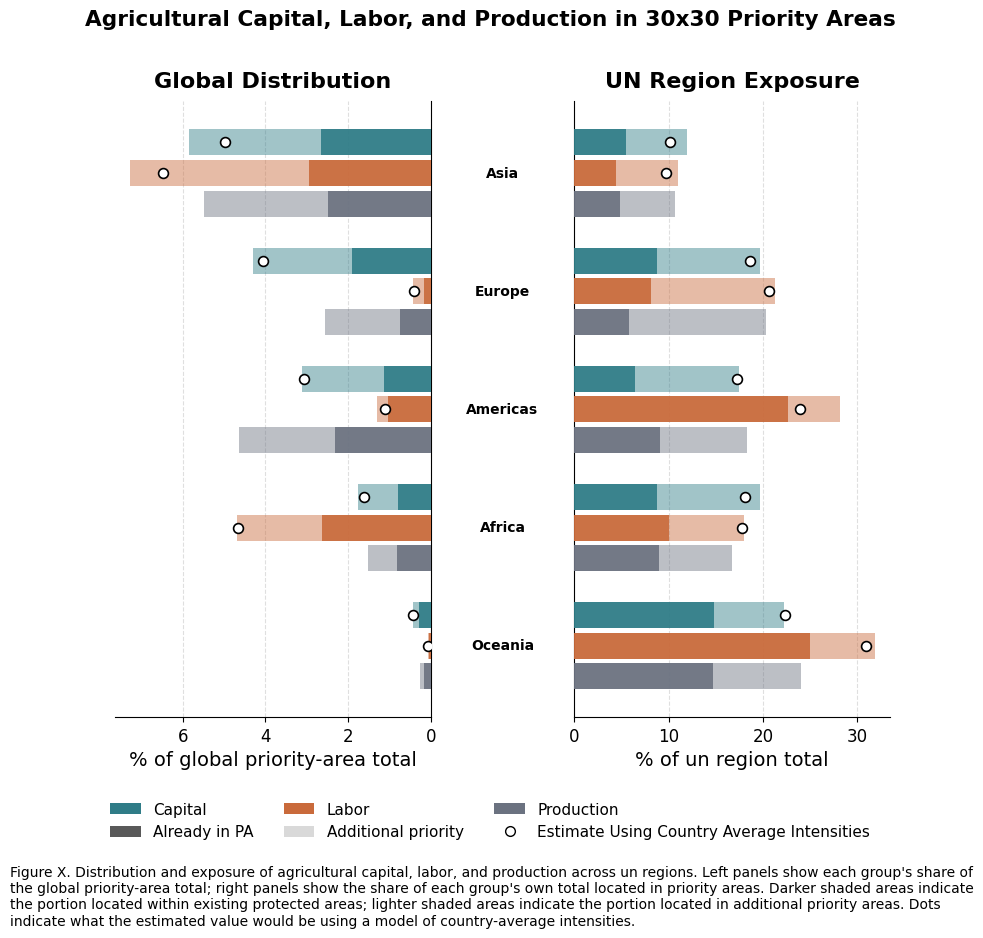

/var/folders/48/ky2jtbmj31bfj15cr5gq480w0000gn/T/ipykernel_10558/683973306.py:310: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


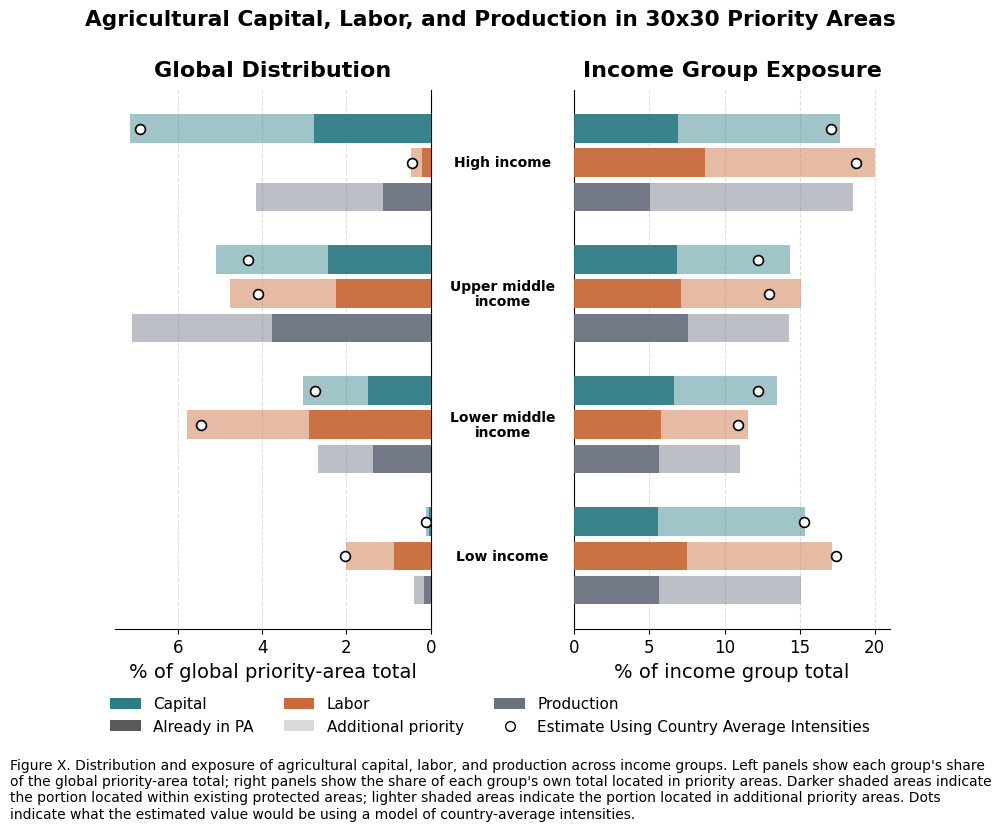

In [8]:
##### Plot income group / region butterfly charts

def plot_group_butterfly(
    group_summary,
    group_avg_summary,
    group_col,
    group_title,
    filename,
    figure_number,
):

    # Rank groups by capital's global share
    capital_rank = (
        group_summary[
            (group_summary["Variable"] == "Capital")
            & (
                group_summary["Class"].isin(
                    [
                        "Additional priority",
                        "Already in PA",
                    ]
                )
            )
        ]
        .groupby(group_col)["Pct_of_global"]
        .sum()
        .sort_values(ascending=False)
    )

    groups = capital_rank.index.tolist()
    n = len(groups)

    bar_h = 0.22
    offset = bar_h + 0.04
    y_positions = np.arange(n)[::-1]

    fig = plt.figure(
        figsize=(10, 1 * n + 3)
    )

    gs = gridspec.GridSpec(
        1,
        3,
        width_ratios=[4, 1.5, 4],
        wspace=0.05,
    )

    ax_left = fig.add_subplot(gs[0])
    ax_mid = fig.add_subplot(gs[1], sharey=ax_left)
    ax_right = fig.add_subplot(gs[2], sharey=ax_left)

    for y, group in zip(
        y_positions,
        groups,
    ):

        for variable, y_off in [
            ("Capital", offset),
            ("Labor", 0),
            ("Production", -offset),
        ]:

            sub = group_summary[
                (group_summary[group_col] == group)
                & (group_summary["Variable"] == variable)
            ]

            already_g = sub.loc[
                sub["Class"] == "Already in PA",
                "Pct_of_global",
            ].sum()

            additional_g = sub.loc[
                sub["Class"] == "Additional priority",
                "Pct_of_global",
            ].sum()

            already_n = sub.loc[
                sub["Class"] == "Already in PA",
                "Pct_of_group",
            ].sum()

            additional_n = sub.loc[
                sub["Class"] == "Additional priority",
                "Pct_of_group",
            ].sum()

            # Global distribution
            ax_left.barh(
                y + y_off,
                already_g,
                bar_h,
                color=COLORS[variable],
                alpha=0.95,
                zorder=3,
            )

            ax_left.barh(
                y + y_off,
                additional_g,
                bar_h,
                left=already_g,
                color=COLORS[variable],
                alpha=0.45,
                zorder=3,
            )

            # Group exposure
            ax_right.barh(
                y + y_off,
                already_n,
                bar_h,
                color=COLORS[variable],
                alpha=0.95,
                zorder=3,
            )

            ax_right.barh(
                y + y_off,
                additional_n,
                bar_h,
                left=already_n,
                color=COLORS[variable],
                alpha=0.45,
                zorder=3,
            )

            # Country-average estimate
            avg_sub = group_avg_summary[
                (group_avg_summary[group_col] == group)
                & (group_avg_summary["Variable"] == variable)
            ]

            if not avg_sub.empty:

                avg_global = avg_sub[
                    "Pct_of_global"
                ].sum()

                avg_group = avg_sub[
                    "Pct_of_group"
                ].sum()

                if pd.notna(avg_global):
                    ax_left.scatter(
                        avg_global,
                        y + y_off,
                        marker="o",
                        s=50,
                        facecolor="white",
                        edgecolor="black",
                        linewidth=1.2,
                        zorder=6,
                    )

                if pd.notna(avg_group):
                    ax_right.scatter(
                        avg_group,
                        y + y_off,
                        marker="o",
                        s=50,
                        facecolor="white",
                        edgecolor="black",
                        linewidth=1.2,
                        zorder=6,
                    )

    # Left panel
    ax_left.set_xlabel(
        "% of global priority-area total"
    )

    ax_left.invert_xaxis()

    ax_left.spines[
        ["top", "left"]
    ].set_visible(False)

    ax_left.grid(
        axis="x",
        linestyle="--",
        alpha=0.4,
        zorder=0,
    )

    ax_left.set_axisbelow(True)

    ax_left.set_title(
        "Global Distribution",
        fontweight="bold",
        pad=10,
    )

    ax_left.yaxis.set_visible(False)

    # Right panel
    ax_right.set_xlabel(
        f"% of {group_title.lower()} total"
    )

    ax_right.spines[
        ["top", "right"]
    ].set_visible(False)

    ax_right.grid(
        axis="x",
        linestyle="--",
        alpha=0.4,
        zorder=0,
    )

    ax_right.set_axisbelow(True)

    ax_right.set_title(
        f"{group_title} Exposure",
        fontweight="bold",
        pad=10,
    )

    ax_right.yaxis.set_visible(False)

    # Middle labels
    ax_mid.axis("off")

    for y, group in zip(
        y_positions,
        groups,
    ):
        wrapped_label = "\n".join(
            textwrap.wrap(str(group), width=14)
        )

        ax_mid.text(
            0.5,
            y,
            wrapped_label,
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            linespacing=1.1,
        )

    # Simplified legend — order interleaved for column-major fill:
    # col1: Capital/Already in PA, col2: Labor/Additional priority, col3: Production/Estimate
    legend_elements = [
        Patch(
            facecolor=COLORS["Capital"],
            label="Capital",
        ),
        Patch(
            facecolor=STATUS_COLORS["Already in PA"],
            label="Already in PA",
        ),
        Patch(
            facecolor=COLORS["Labor"],
            label="Labor",
        ),
        Patch(
            facecolor=STATUS_COLORS["Additional priority"],
            label="Additional priority",
        ),
        Patch(
            facecolor=COLORS["Production"],
            label="Production",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            color="black",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=7,
            linewidth=0,
            label="Estimate Using Country Average Intensities",
        ),
    ]

    fig.legend(
        handles=legend_elements,
        loc="lower center",
        ncol=3,
        bbox_to_anchor=(0.5, -0.06),
        frameon=False,
    )

    fig.suptitle(
        "Agricultural Capital, Labor, and Production in 30x30 Priority Areas",
        fontweight="bold",
        y=0.995,
    )

    fig.text(
        0.02,
        -0.075,
        f"Figure X. Distribution and exposure of agricultural capital, "
        f"labor, and production across {group_title.lower()}s. Left panels show each "
        f"group's share of the global priority-area total; right panels show the share "
        f"of each group's own total located in priority areas. Darker shaded areas "
        f"indicate the portion located within existing protected areas; lighter shaded "
        f"areas indicate the portion located in additional priority areas. Dots indicate "
        f"what the estimated value would be using a model of country-average intensities.",
        ha="left",
        va="top",
        fontsize=10,
        wrap=True,
    )

    plt.tight_layout(
        rect=[0, 0.05, 1, 0.97]
    )

    plt.savefig(
        f"{fd}/{filename}",
        dpi=250,
        bbox_inches="tight",
    )

    plt.show()


# UN regions 
plot_group_butterfly(
    region_summary,
    region_avg_summary,
    "UN_region",
    "UN Region",
    "Figure_3_UN_regions_biodiversity.png",
    3,
)


# Income groups
plot_group_butterfly(
    income_summary,
    income_avg_summary,
    "income_group",
    "Income Group",
    "Figure_3_income_groups_biodiversity.png",
    4,
)

#### Figure 4: Map of priority areas

/var/folders/48/ky2jtbmj31bfj15cr5gq480w0000gn/T/ipykernel_10558/2683989191.py:13: RuntimeWarning: invalid value encountered in cast
  bio_arr.astype(np.int8),


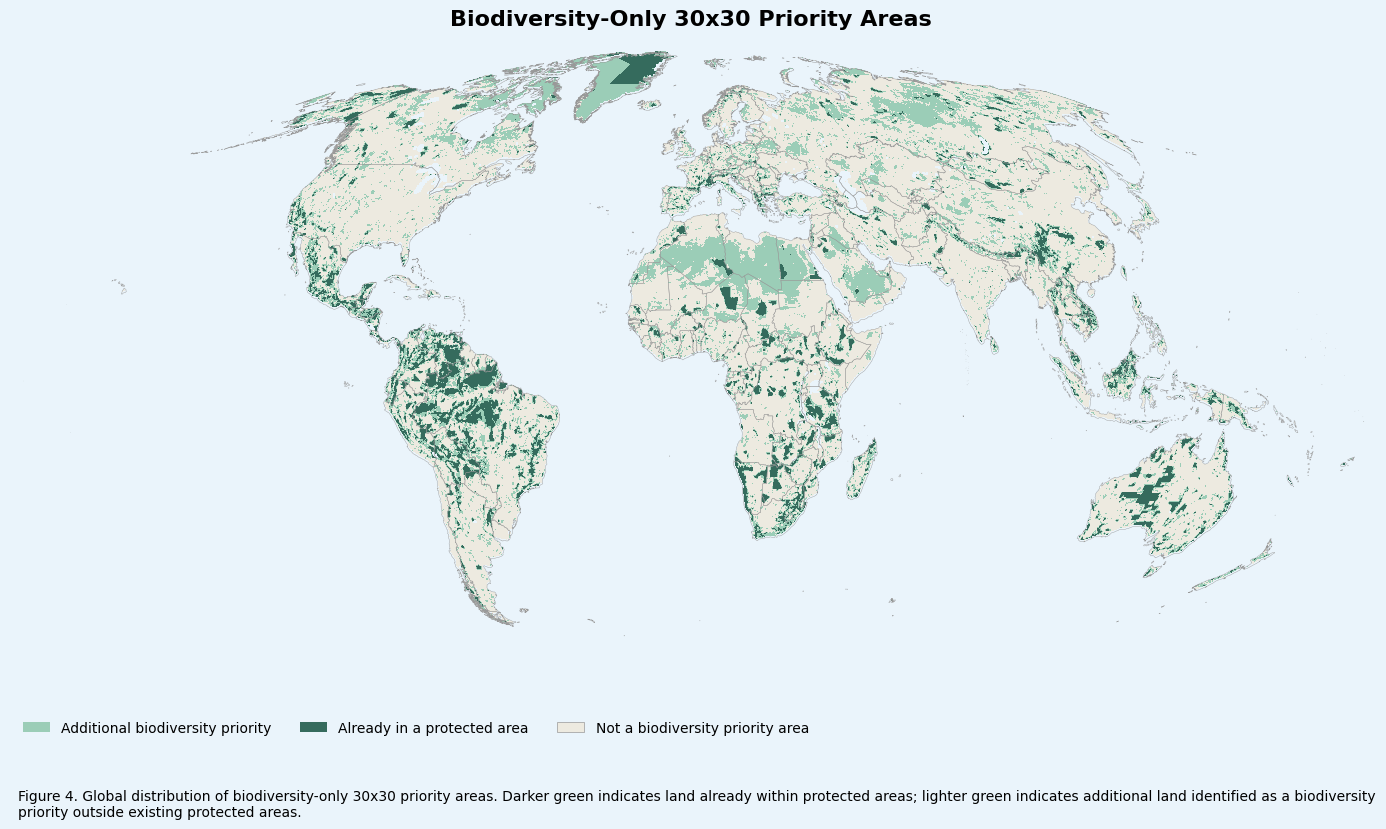

In [9]:
##### Map of priority areas 

# Biodiversity raster:
# 0 = not priority
# 1 = additional biodiversity priority
# 2 = already protected area

bio_arr = read_array(biodiversity_with_PA)

map_class = np.where(
    np.isnan(bio_arr),
    -1,
    bio_arr.astype(np.int8),
)

masked_map = np.ma.masked_where(map_class == -1, map_class)

# A simple green palette for the biodiversity-only scenario
map_colors = [
    "#EDEAE0",  # 0 — not priority
    "#9BCDB7",  # 1 — additional priority
    "#356B5D",  # 2 — already in PA
]

cmap = mcolors.ListedColormap(map_colors)
norm = mcolors.BoundaryNorm(
    [-0.5, 0.5, 1.5, 2.5],
    cmap.N,
)


# Match country boundaries to raster CRS
with rasterio.open(biodiversity_with_PA) as src:
    raster_transform = src.transform
    raster_crs = src.crs

country_ctx = (
    country_simple.to_crs(raster_crs)
    if country_simple.crs != raster_crs
    else country_simple
)


# Plot
fig, ax = plt.subplots(figsize=(14, 8))

# Ocean/background
fig.patch.set_facecolor("#EAF4FB")
ax.set_facecolor("#EAF4FB")

country_ctx.boundary.plot(
    ax=ax,
    color="#999999",
    linewidth=0.3,
    zorder=2,
)

show(
    masked_map,
    transform=raster_transform,
    ax=ax,
    cmap=cmap,
    norm=norm,
    zorder=1,
)

ax.set_axis_off()

ax.set_title(
    "Biodiversity-Only 30x30 Priority Areas",
    fontsize=16,
    fontweight="bold",
    pad=16,
)

legend_elements = [
    Patch(
        facecolor=map_colors[1],
        edgecolor="none",
        label="Additional biodiversity priority",
    ),
    Patch(
        facecolor=map_colors[2],
        edgecolor="none",
        label="Already in a protected area",
    ),
    Patch(
        facecolor=map_colors[0],
        edgecolor="#999999",
        linewidth=0.5,
        label="Not a biodiversity priority area",
    ),
]

ax.legend(
    handles=legend_elements,
    loc="lower left",
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.0, -0.05),
    ncol=3,
)

fig.text(
    0.02,
    -0.01,
    "Figure 4. Global distribution of biodiversity-only 30x30 priority areas. "
    "Darker green indicates land already within protected areas; lighter green indicates "
    "additional land identified as a biodiversity priority outside existing protected areas.",
    ha="left",
    va="top",
    fontsize=10,
    wrap=True,
)

plt.tight_layout()
plt.savefig(
    f"{fd}/Figure_4_biodiversity_priority_map.png",
    dpi=250,
    bbox_inches="tight",
)
plt.show()